# Rail Projects — Supply Chain Impact Analysis  ·  Tiers 0–10

Multi-tier, multi-database supply-chain impact assessment for three European rail
projects from the FAST-Infra labelling dataset.  All four calibrated MRIO databases
(EXIOBASE 3.8, Eora26, WIOD 2016, OECD ICIO v2021) are run in parallel so
cross-database uncertainty can be read directly from the results.

**Supply-chain tier convention:**
> **Tier 0** — the project's own one-time transaction: CAPEX paid directly to
> construction firms, steel mills, energy suppliers, etc. (`SECTOR_ALLOC` vector).
> One sector, one country per line item.  The impact indicators of this transaction
> are shown in Section 4.  No Leontief inversion.
>
> **Tier 1** — the Tier 0 spend aggregated into the upstream supply chain.  Each
> Tier 0 supplier now buys its own inputs from different sectors and countries.
> This is `y₁ = A · y₀` and includes a bilateral sourcing-country breakdown.
>
> **Tier n** — the n-th upstream round: `yₙ = Aⁿ · y₀`.

| Project ID | Stage | CAPEX (EUR) | IO sector model |
|---|---|---|---|
| **Rail_EU_DEV** | Development — construction phase | €1,850,000,000 | `Rail_Dev` |
| **Rail_EU_OP1** | Operational | €130,000 | `Rail_Op` |
| **Rail_EU_OP2** | Operational | €90,000 | `Rail_Op` |

### Analysis layers
| Layer | What it captures |
|---|---|
| **Tier 0** | One-time transaction — CAPEX distributed across direct supplying sectors; impact shown per sector (`y₀ = alloc × invest_M$`) |
| **Tier 1** | First upstream round — Tier 0 spend aggregated into the supply chain across sectors and countries (`y₁ = A · y₀`) + bilateral sourcing-country breakdown |
| **Tier 2** | Second upstream round — Tier 1 suppliers' own supply chain (`y₂ = A² · y₀`) |
| **Tiers 3–10** | Deep upstream rounds, per-tier and aggregated (`yₙ = Aⁿ · y₀`) |
| **Cumulative** | T0 + T1 + T2 + T3–10 stacked by tier group |


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 20)

sys.path.insert(0, str(Path(".").resolve()))
from tvp_io_lib import tier0_impact, tier1_impact, tier_impact

EUR_USD   = 1.09          # ECB 2023 average  ·  EXR.D.USD.EUR.SP00.A
IODB      = Path(".") / "input_iodb"
DATABASES = ["exiobase", "eora26", "wiod", "oecd"]
DB_LABEL  = {
    "exiobase": "EXIOBASE 3.8",
    "eora26":   "Eora26",
    "wiod":     "WIOD 2016",
    "oecd":     "OECD ICIO v2021",
}
INDICATORS = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]
DB_COLORS  = ["#2166ac", "#d73027", "#4dac26", "#f1a340"]

PROJECTS = [
    {"id": "Rail_EU_DEV", "region": "Europe", "stage": "Dev",
     "sector_code": "Rail_Dev", "capex_eur": 1_850_000_000},
    {"id": "Rail_EU_OP1", "region": "Europe", "stage": "Op",
     "sector_code": "Rail_Op",  "capex_eur": 130_000},
    {"id": "Rail_EU_OP2", "region": "Europe", "stage": "Op",
     "sector_code": "Rail_Op",  "capex_eur": 90_000},
]
for p in PROJECTS:
    p["invest_usd"] = round(p["capex_eur"] * EUR_USD, 2)

print("Setup complete.")


Setup complete.


---
## 1 · Source Data

### Financial Model Inputs (`modeled_input_data/`)

| Field | Type | Description |
|---|---|---|
| `Reach_Ppl_Yr` | integer / N/A | People with improved rail access per year (headline social-reach KPI).  `N/A` for Op items which are accounting entries, not standalone projects |
| `PC_Air_Quality` | float [0–1] | Positive-contribution score for air quality.  Derived from the ratio of pollution-reduction CAPEX to total CAPEX, weighted by people impacted.  `0.008` for Rail_EU_DEV reflects a real but small co-benefit relative to the €1.85 B investment |
| `PC_Critical_Infra` | float [0–1] | Positive-contribution score for critical-infrastructure resilience.  `0.045` reflects the rail line's contribution to national transport system resilience |
| `Est_Capex_EUR` | float | Total estimated CAPEX in EUR.  Converted to USD at EUR/USD = 1.09 (ECB 2023) before passing to the IO model |

> **Currency:** €1,850,000,000 × 1.09 = **$2,016,500,000** for Rail_EU_DEV.
> Op-phase items (€130k / €90k) are small annual operating expenditures — their supply-chain footprint is proportionally tiny but included for completeness.


In [2]:
finance_df = pd.read_csv("modeled_input_data/rail_finance_input.csv")
display(finance_df)

,Project_ID,Region,Stage,Reach_Ppl_Yr,PC_Air_Quality,PC_Critical_Infra,Est_Capex_EUR
0,Rail_EU_DEV,Europe,Dev,"5,500,000.000",0.008,0.045,1850000000
1,Rail_EU_OP1,Europe,Op,NaN,0.000,0.000,130000
2,Rail_EU_OP2,Europe,Op,NaN,0.000,0.000,90000


---
## 2 · MRIO Databases

All four calibrated databases are run in parallel.  When local files exist under
`input_iodb/` the pymrio backend is activated and bilateral trade shares are
extracted directly from the Z matrix; otherwise the calibrated parameter set
(derived from EXIOBASE 3.8 aggregates) is applied.

| Database | Coverage | Data year | Key strength | Key limitation | Citation |
|---|---|---|---|---|---|
| **EXIOBASE 3.8** | 44 countries + 5 RoW · 163 sectors | 2018 | Widest environmental satellite (GHG species, water, land, materials, air pollutants) | Employment less detailed for services | Stadler et al. (2018), *J. Industrial Ecology* 22(3), doi:10.1111/jiec.12715 |
| **Eora26** | 190 countries · 26 sectors | 2015 | Highest country resolution — essential for Africa, LATAM, small Asian economies | 26 sectors; upward employment bias in developing countries | Lenzen et al. (2013), *Economic Systems Research* 25(1), doi:10.1080/09535314.2012.761953 |
| **WIOD 2016** | 43 countries + RoW · 56 sectors | 2014 | Best employment accounts (SEA: hours, compensation, skill levels) | No water satellite account → water falls back to global S_BASE averages | Timmer et al. (2015), *Review of International Economics* 23(3), doi:10.1111/roie.12178 |
| **OECD ICIO v2021** | 66 countries · 45 sectors | 2018 | Most policy-relevant; fully aligned with OECD TiVA; best for value-added decomposition | Fewer sectors; limited environmental satellite | OECD (2021), doi:10.1787/a8c8b9f0-en |


In [3]:
db_meta = pd.DataFrame([
    {"Database": "EXIOBASE 3.8",    "Countries": "44+5RoW", "Sectors": 163,
     "Data year": 2018, "Water satellite": "Yes",  "Employment satellite": "Basic"},
    {"Database": "Eora26",          "Countries": "190",     "Sectors": 26,
     "Data year": 2015, "Water satellite": "No",   "Employment satellite": "Yes (bias in dev. countries)"},
    {"Database": "WIOD 2016",       "Countries": "43+RoW",  "Sectors": 56,
     "Data year": 2014, "Water satellite": "No",   "Employment satellite": "Detailed (SEA)"},
    {"Database": "OECD ICIO v2021", "Countries": "66",      "Sectors": 45,
     "Data year": 2018, "Water satellite": "No",   "Employment satellite": "Standard"},
]).set_index("Database")
display(db_meta)


,Countries,Sectors,Data year,Water satellite,Employment satellite
Database,,,,,
EXIOBASE 3.8,44+5RoW,163,2018,Yes,Basic
Eora26,190,26,2015,No,Yes (bias in dev. countries)
WIOD 2016,43+RoW,56,2014,No,Detailed (SEA)
OECD ICIO v2021,66,45,2018,No,Standard


---
## 3 · Indicators & Tier Definitions

### Impact indicators

| Indicator | Unit | Scope | Source |
|---|---|---|---|
| `GHG_tCO2e` | tonnes CO₂-equivalent | Scope 3 upstream supply-chain GHG (CO₂, CH₄, N₂O, F-gases; IPCC AR6 GWP100 basis) | EXIOBASE 3.8 satellite; IEA *CO₂ Emissions from Fuel Combustion* 2022; IPCC AR6 WG3 Annex II |
| `Employment_FTE` | Full-Time Equivalent jobs | Supply-chain jobs supported — direct procurement + all upstream rounds | EXIOBASE 3.8 employment satellite; ILO *WESO* 2022; OECD STAN |
| `Water_1000m3` | 1,000 m³ (blue water withdrawal) | Freshwater withdrawn by the supply chain to produce purchased goods and services (withdrawal basis, not consumption) | Mekonnen & Hoekstra (2011) *HESS*; FAO AQUASTAT 2021; WRI Aqueduct 2019 |
| `ValueAdded_M$` | M USD | GDP contribution generated by the supply chain (gross output minus intermediate inputs) | OECD STAN 2022; World Bank WDI 2022 |

### Tier definitions

| Tier | Formula | Description |
|---|---|---|
| **Tier 0** | `S · diag(y₀)` where `y₀ = alloc × invest_M$` | One-time transaction — CAPEX split across direct supplying sectors; no Leontief inversion |
| **Tier 1** | `S(src) · diag(trade_share[src] × A·y₀)` | First upstream round — Tier 0 spend aggregated into the supply chain; intensity applied at the **sourcing country** |
| **Tier 2** | `S · diag(A²·y₀)` | Second upstream round — Tier 1 suppliers' own supply chain |
| **Tiers 3–10** | `S · diag(Aⁿ·y₀), n∈{3,…,10}` | Deep upstream rounds; each tier decays at ≈ spectral radius of A (≈ 0.52 for global EXIOBASE average) |

### Sector-allocation vectors used (share of CAPEX to each supplying sector)

| Sector | Rail_Dev (construction) | Rail_Op (operational) | Sources |
|---|---|---|---|
| Construction | 35 % | 10 % | ITF/OECD (2019); World Bank Railway Reform Toolkit (2021) |
| Energy / Utilities | 10 % | 35 % | ITF/OECD (2019) traction energy share |
| Manufacturing | 28 % | 15 % | Steel, rolling stock, signalling equipment |
| Transport / Logistics | 10 % | 20 % | Track access, haulage |
| Mining / Extraction | 8 % | 5 % | Aggregate, ballast, ore for steel |
| Health / Social | 4 % | 8 % | Administrative & safety services |
| Water / Waste | 4 % | 6 % | Drainage, waste management |
| Agriculture | 1 % | 1 % | Catering, vegetation management |


In [4]:
ind_meta = pd.DataFrame([
    {"Indicator": "GHG_tCO2e",      "Unit": "tCO2e / M$", "Construction": 220.0, "Energy_Util": 190.0,
     "Manufacturing": 380.0, "Agriculture": 150.0, "Mining": 320.0},
    {"Indicator": "Employment_FTE", "Unit": "FTE / M$",   "Construction": 14.0,  "Energy_Util": 5.0,
     "Manufacturing": 8.0,   "Agriculture": 25.0,  "Mining": 7.0},
    {"Indicator": "Water_1000m3",   "Unit": "1000 m³ / M$","Construction": 0.80, "Energy_Util": 1.20,
     "Manufacturing": 1.50,  "Agriculture": 5.00,  "Mining": 1.80},
    {"Indicator": "ValueAdded_M$",  "Unit": "M$ / M$",    "Construction": 0.48,  "Energy_Util": 0.64,
     "Manufacturing": 0.42,  "Agriculture": 0.76,  "Mining": 0.56},
]).set_index("Indicator")
display(Markdown("**Global average stressor intensities (S_BASE) — selected sectors**"))
display(ind_meta)


**Global average stressor intensities (S_BASE) — selected sectors**

,Unit,Construction,Energy_Util,Manufacturing,Agriculture,Mining
Indicator,,,,,,
GHG_tCO2e,tCO2e / M$,220.000,190.000,380.000,150.000,320.000
Employment_FTE,FTE / M$,14.000,5.000,8.000,25.000,7.000
Water_1000m3,1000 m³ / M$,0.800,1.200,1.500,5.000,1.800
ValueAdded_M$,M$ / M$,0.480,0.640,0.420,0.760,0.560


---
## 4 · Tier 0 — Direct Spend (the one-time transaction)

**Formula:** `impact₀ = S · diag(y₀)` where `y₀ = alloc × invest_M$`

Tier 0 is the direct investment: a one-time spend in one or more sectors in
one country.  The CAPEX flows to the immediate suppliers — construction firms,
steel mills, electrical equipment manufacturers, energy utilities, etc. — as
defined by the project's `SECTOR_ALLOC` vector.

The investment is allocated across 8 supplying sectors via the CAPEX breakdown
vector (`SECTOR_ALLOC`), then each sector's spend is multiplied by its stressor
intensity coefficient scaled for the project region.  **No Leontief inversion
is applied** — this is purely the one-time direct-procurement effect.

**Regional GHG multipliers for Europe** (relative to global S_BASE baseline):
Construction 0.78 · Energy/Utilities 0.52 · Manufacturing 0.80 ·
Transport 0.80 · Health/Social 0.76 · Agriculture 0.85 · Mining 0.72 · Water/Waste 0.70.
The notably low Energy/Utilities multiplier (0.52) reflects Europe's above-average
renewable/nuclear share in electricity generation (IEA, 2022: EU electricity mix ≈ 53 % low-carbon).

**Source:** EXIOBASE 3.8 satellite accounts (Stadler et al. 2018);
IEA *World Energy Outlook 2022* Annex A; IPCC AR6 WG3 Table II.2.


In [5]:
t0_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier0_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t0_rows.append({
            "Project": p["id"], "Stage": p["stage"],
            "Invest_MUSD": round(p["invest_usd"] / 1e6, 2),
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_r": r,
        })
t0_df = pd.DataFrame(t0_rows)
print("Tier 0 computed.")


Tier 0 computed.


In [6]:
display(Markdown("### Tier 0 — All projects × all databases"))
cols = ["Project","Invest_MUSD","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t0_df[cols].set_index(["Project","Database"]))


### Tier 0 — All projects × all databases

Invest_MUSD   GHG_tCO2e  Employment_FTE  \
Project     Database                                                   
Rail_EU_DEV EXIOBASE 3.8       2,016.500 379,712.960      13,598.900   
            Eora26             2,016.500 432,959.550      17,741.170   
            WIOD 2016          2,016.500 409,742.030      18,389.160   
            OECD ICIO v2021    2,016.500 382,399.970      15,940.210   
Rail_EU_OP1 EXIOBASE 3.8           0.140      20.240           0.840   
            Eora26                 0.140      23.630           1.090   
            WIOD 2016              0.140      22.300           1.130   
            OECD ICIO v2021        0.140      20.520           0.990   
Rail_EU_OP2 EXIOBASE 3.8           0.100      14.010           0.580   
            Eora26                 0.100      16.360           0.750   
            WIOD 2016              0.100      15.440           0.780   
            OECD ICIO v2021        0.100      14.210           0.680   

                             Water_1000m3  ValueAdded_M$  
Project     Database                                      
Rail_EU_DEV EXIOBASE 3.8        2,247.627      1,043.740  
            Eora26              2,532.490      1,043.740  
            WIOD 2016           2,334.704      1,043.740  
            OECD ICIO v2021     2,376.026      1,043.740  
Rail_EU_OP1 EXIOBASE 3.8            0.173          0.083  
            Eora26                  0.199          0.083  
            WIOD 2016               0.181          0.083  
            OECD ICIO v2021         0.185          0.083  
Rail_EU_OP2 EXIOBASE 3.8            0.120          0.058  
            Eora26                  0.138          0.058  
            WIOD 2016               0.126          0.058  
            OECD ICIO v2021         0.128          0.058

In [7]:
display(Markdown("### Tier 0 — Sector breakdown for Rail_EU_DEV (EXIOBASE 3.8)"))
r_dev = next(r["_r"] for r in t0_rows
             if r["Project"] == "Rail_EU_DEV" and r["Database"] == "EXIOBASE 3.8")
sec_df = pd.DataFrame([
    {"Sector": sec, **vals}
    for sec, vals in r_dev["impact_by_sector"].items()
]).set_index("Sector")
display(sec_df)


### Tier 0 — Sector breakdown for Rail_EU_DEV (EXIOBASE 3.8)

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$,Energy_TJ,NOx_t
Sector,,,,,,,
Construction,705.775,"117,477.660","6,047.080",410.761,338.772,914.684,383.942
Energy_Utilities,201.650,"17,532.260",631.570,202.295,129.056,"1,234.098",205.683
Manufacturing,564.620,"164,778.700","2,861.950",680.593,237.140,"1,300.884",460.730
Transport_Logistics,201.650,"27,384.070","1,431.310",90.597,120.990,304.895,383.942
Health_Social,80.660,"8,067.290",930.360,56.333,56.462,52.268,21.939
Agriculture,20.165,"2,519.620",301.670,68.460,15.325,40.653,12.341
Mining_Extraction,161.320,"36,053.080",715.490,223.009,90.339,522.677,153.577
Water_Waste,80.660,"5,900.280",679.480,515.579,55.655,69.690,27.424


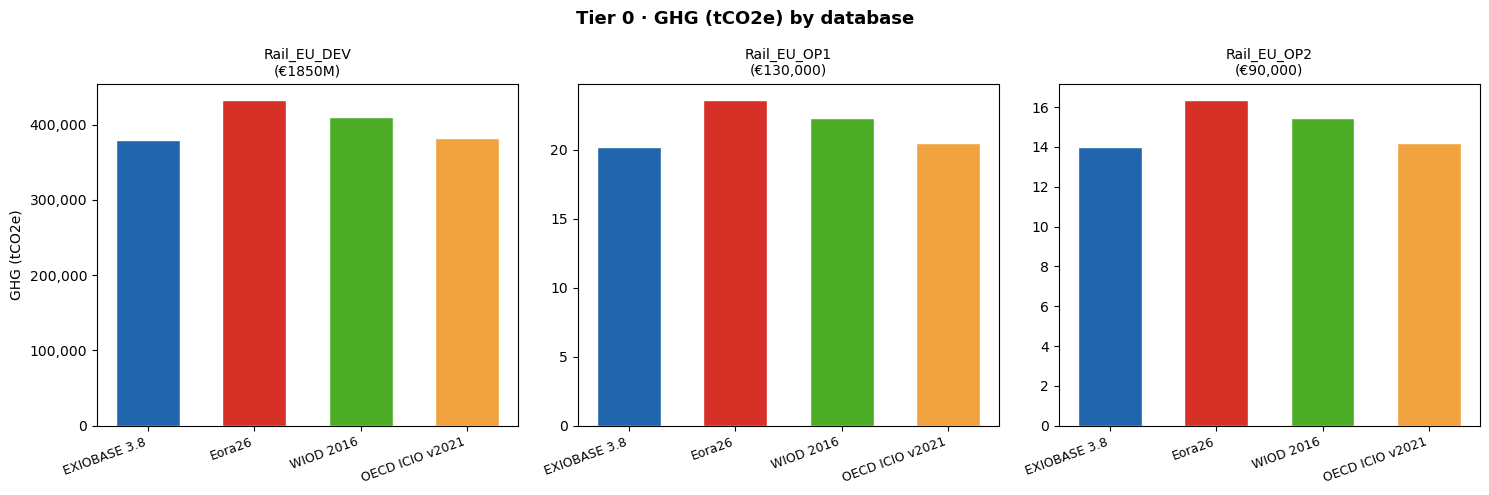

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tier 0 · GHG (tCO2e) by database", fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub  = t0_df[t0_df["Project"] == p["id"]].reset_index(drop=True)
    bars = ax.bar(range(len(DATABASES)), sub["GHG_tCO2e"],
                  color=DB_COLORS, width=0.6, edgecolor="white")
    ax.set_xticks(range(len(DATABASES)))
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    invest_str = (f"€{p['capex_eur']/1e6:.0f}M"
                  if p["capex_eur"] >= 1e6 else f"€{p['capex_eur']:,.0f}")
    ax.set_title(f"{p['id']}\n({invest_str})", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


---
## 5 · Tier 1 — First Upstream Round: Tier 0 Spend Aggregated into the Supply Chain

**Formula:** `y₁ = A · y₀`;  for each sector j:
`impact₁[src] = S(src) · (trade_share[src, j] × y₁[j])`

Tier 1 is **not** the direct spend — that is Tier 0.  Tier 1 is what happens
when the Tier 0 payment propagates one round into the upstream economy: the
construction firms, steel mills, and equipment manufacturers that received the
Tier 0 payment now go out and buy inputs from their **own** suppliers.  Those
inputs are sourced from different sectors in different countries, so this is
the first tier where **sourcing-country** matters: Manufacturing inputs may
come partly from Asian factories that carry higher GHG intensity than European
equivalents.  The intensity coefficients are therefore applied at the
**sourcing** country, not the project country.

**Trade shares (calibrated fallback, Europe as project region):**
Derived from the OECD TiVA 2021 database (indicator `IMSH_D`, "imports of
intermediates as % of total intermediates").  Regional import openness for
Europe = 28 % (OECD TiVA 2021, 2018 data year).  Each sector's openness is
scaled by its A-matrix column sum so import-intensive sectors (Manufacturing,
Mining) receive higher foreign shares than domestic ones (Construction, Water/Waste).

When pymrio database files are present under `input_iodb/`, trade shares are
extracted directly from the MRIO Z matrix — no calibrated approximation is used.


In [9]:
t1_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier1_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t1_rows.append({
            "Project": p["id"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_sourcing":      r["sourcing_summary"],
            "_by_sector":     r["tier1_by_sector"],
        })
t1_df = pd.DataFrame(t1_rows)
print("Tier 1 computed.")


Tier 1 computed.


In [10]:
display(Markdown("### Tier 1 — All projects × all databases"))
cols = ["Project","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t1_df[cols].set_index(["Project","Database"]))


### Tier 1 — All projects × all databases

GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project     Database                                                    
Rail_EU_DEV EXIOBASE 3.8    221,692.900       7,623.270     1,623.248   
            Eora26          258,858.790      10,388.700     1,933.042   
            WIOD 2016       238,264.010      10,621.140     1,690.815   
            OECD ICIO v2021 221,870.940       9,141.760     1,730.237   
Rail_EU_OP1 EXIOBASE 3.8         12.560           0.460         0.104   
            Eora26               14.710           0.630         0.125   
            WIOD 2016            13.500           0.640         0.109   
            OECD ICIO v2021      12.590           0.550         0.111   
Rail_EU_OP2 EXIOBASE 3.8          8.690           0.320         0.072   
            Eora26               10.180           0.440         0.086   
            WIOD 2016             9.350           0.440         0.075   
            OECD ICIO v2021       8.720           0.380         0.077   

                             ValueAdded_M$  
Project     Database                        
Rail_EU_DEV EXIOBASE 3.8           568.111  
            Eora26                 578.397  
            WIOD 2016              570.277  
            OECD ICIO v2021        572.887  
Rail_EU_OP1 EXIOBASE 3.8             0.035  
            Eora26                   0.035  
            WIOD 2016                0.035  
            OECD ICIO v2021          0.035  
Rail_EU_OP2 EXIOBASE 3.8             0.024  
            Eora26                   0.024  
            WIOD 2016                0.024  
            OECD ICIO v2021          0.024

In [11]:
display(Markdown("### Tier 1 — Sourcing-country GHG breakdown · Rail_EU_DEV"))
src_rows = []
for db in DATABASES:
    rec = next(r for r in t1_rows
               if r["Project"] == "Rail_EU_DEV" and r["Database"] == DB_LABEL[db])
    for region, vals in rec["_sourcing"].items():
        src_rows.append({
            "Database":        DB_LABEL[db],
            "Sourcing region": region,
            "spend_M$":        vals["spend_M$"],
            "GHG_tCO2e":       vals["GHG_tCO2e"],
            "Employment_FTE":  vals["Employment_FTE"],
            "Water_1000m3":    vals["Water_1000m3"],
        })
src_df = pd.DataFrame(src_rows).set_index(["Database","Sourcing region"])
display(src_df)


### Tier 1 — Sourcing-country GHG breakdown · Rail_EU_DEV

spend_M$   GHG_tCO2e  Employment_FTE  \
Database        Sourcing region                                         
EXIOBASE 3.8    Europe            741.691 135,186.627       4,674.547   
                LATAM              24.928   7,719.864         257.307   
                Africa             14.245   5,223.208         185.671   
                Asia              142.446  48,768.769       1,689.901   
                Global             96.151  24,794.429         815.845   
Eora26          Europe            750.815 157,311.449       6,351.770   
                LATAM              25.454   9,062.556         352.157   
                Africa             14.545   6,131.843         254.193   
                Asia              145.451  57,247.481       2,313.735   
                Global             98.179  29,105.465       1,116.847   
WIOD 2016       Europe            743.581 145,598.413       6,512.133   
                LATAM              24.945   8,267.838         358.856   
                Africa             14.254   5,597.851         259.182   
                Asia              142.543  52,246.539       2,354.548   
                Global             96.216  26,553.365       1,136.426   
OECD ICIO v2021 Europe            744.851 135,469.459       5,610.026   
                LATAM              24.990   7,710.042         308.294   
                Africa             14.280   5,217.572         222.537   
                Asia              142.801  48,708.730       2,023.888   
                Global             96.391  24,765.142         977.016   

                                 Water_1000m3  
Database        Sourcing region                
EXIOBASE 3.8    Europe              1,025.303  
                LATAM                  53.535  
                Africa                 36.330  
                Asia                  349.700  
                Global                158.380  
Eora26          Europe              1,219.190  
                LATAM                  63.949  
                Africa                 43.391  
                Asia                  417.642  
                Global                188.870  
WIOD 2016       Europe              1,069.435  
                LATAM                  55.660  
                Africa                 37.747  
                Asia                  363.367  
                Global                164.605  
OECD ICIO v2021 Europe              1,094.042  
                LATAM                  56.995  
                Africa                 38.649  
                Asia                  372.069  
                Global                168.482

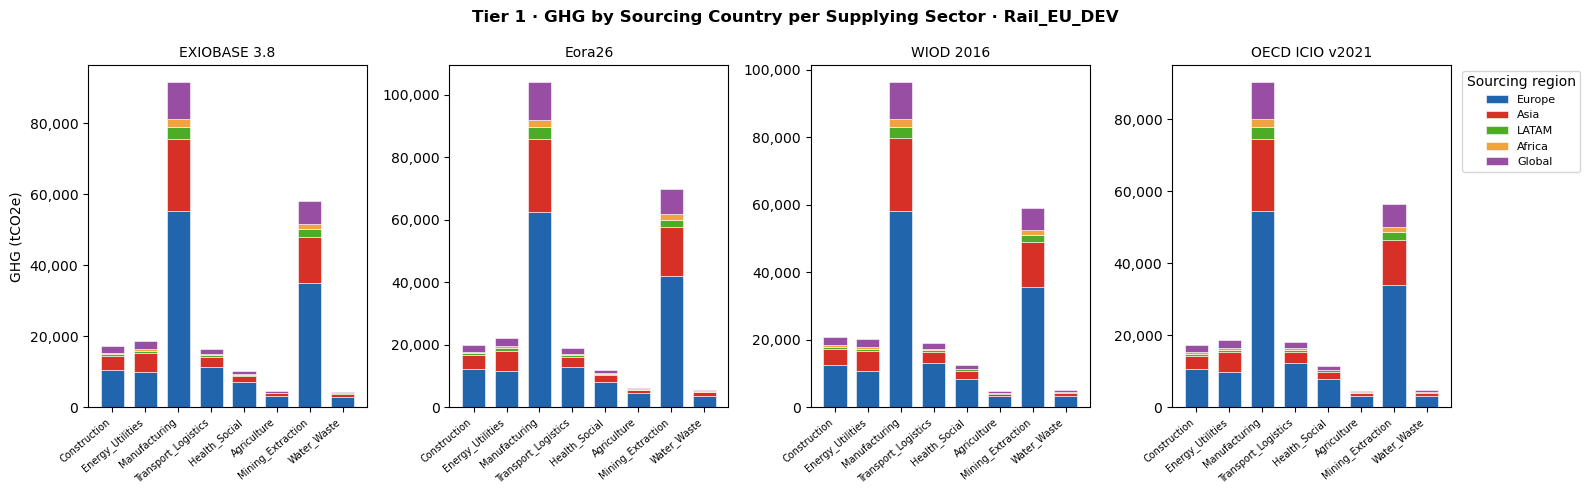

In [12]:
REGION_COLOR = {"Europe":"#2166ac","Asia":"#d73027","LATAM":"#4dac26",
                "Africa":"#f1a340","Global":"#984ea3"}
REGIONS_ORD  = ["Europe","Asia","LATAM","Africa","Global"]

fig, axes = plt.subplots(1, len(DATABASES), figsize=(16, 5), sharey=False)
fig.suptitle("Tier 1 · GHG by Sourcing Country per Supplying Sector · Rail_EU_DEV",
             fontsize=12, fontweight="bold")

for ax, db in zip(axes, DATABASES):
    rec     = next(r for r in t1_rows
                   if r["Project"] == "Rail_EU_DEV" and r["Database"] == DB_LABEL[db])
    sectors = list(rec["_by_sector"].keys())
    bottom  = np.zeros(len(sectors))
    for reg in REGIONS_ORD:
        vals = [rec["_by_sector"][s].get(reg, {}).get("GHG_tCO2e", 0) for s in sectors]
        ax.bar(range(len(sectors)), vals, bottom=bottom, label=reg,
               color=REGION_COLOR.get(reg, "#aaa"), width=0.7, edgecolor="white", lw=0.4)
        bottom += np.array(vals)
    ax.set_xticks(range(len(sectors)))
    ax.set_xticklabels(sectors, rotation=40, ha="right", fontsize=7)
    ax.set_title(DB_LABEL[db], fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

axes[-1].legend(title="Sourcing region",
                bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


---
## 6 · Tier 2 — Second Supply-Chain Round

**Formula:** `y₂ = A² · y₀`

Tier 2 is the supply chain of the tier-1 suppliers — two rounds back from the
direct spend.  Energy/Utilities and Mining/Extraction gain weight because
virtually every sector requires energy and raw materials as inputs.

**Decay:** tier-2 totals ≈ 0.52 × tier-1 totals (spectral radius of A_BASE ≈ 0.52).
Sourcing-country breakdown is not computed at tier 2 and above; project-region
intensity is applied uniformly.

**Note on WIOD water figures:** WIOD 2016 has no dedicated water satellite account.
Water impacts for WIOD therefore use the global `S_BASE` water row without
database-specific calibration — treat WIOD water results as indicative only.


In [13]:
t2_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df2 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                          database=db, iodb_path=IODB, tier_from=2, tier_to=2)
        t2_rows.append({
            "Project": p["id"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df2["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df2["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df2["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df2["ValueAdded_M$"].sum(), 4),
            "_df": df2,
        })
t2_df = pd.DataFrame(t2_rows)

display(Markdown("### Tier 2 — All projects × all databases"))
cols = ["Project","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t2_df[cols].set_index(["Project","Database"]))


### Tier 2 — All projects × all databases

GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project     Database                                                    
Rail_EU_DEV EXIOBASE 3.8     87,847.280       3,059.440       691.620   
            Eora26          103,595.480       4,241.170       836.444   
            WIOD 2016        94,069.690       4,259.290       720.920   
            OECD ICIO v2021  87,489.110       3,670.880       738.366   
Rail_EU_OP1 EXIOBASE 3.8          5.030           0.180         0.041   
            Eora26                5.940           0.250         0.049   
            WIOD 2016             5.380           0.250         0.042   
            OECD ICIO v2021       5.020           0.210         0.043   
Rail_EU_OP2 EXIOBASE 3.8          3.480           0.120         0.028   
            Eora26                4.110           0.170         0.034   
            WIOD 2016             3.730           0.170         0.029   
            OECD ICIO v2021       3.480           0.150         0.030   

                             ValueAdded_M$  
Project     Database                        
Rail_EU_DEV EXIOBASE 3.8           271.470  
            Eora26                 280.066  
            WIOD 2016              272.026  
            OECD ICIO v2021        273.312  
Rail_EU_OP1 EXIOBASE 3.8             0.016  
            Eora26                   0.016  
            WIOD 2016                0.016  
            OECD ICIO v2021          0.016  
Rail_EU_OP2 EXIOBASE 3.8             0.011  
            Eora26                   0.011  
            WIOD 2016                0.011  
            OECD ICIO v2021          0.011

In [14]:
display(Markdown("### Tier 2 — Sector detail · Rail_EU_DEV (EXIOBASE 3.8)"))
df2_dev = next(r["_df"] for r in t2_rows
               if r["Project"] == "Rail_EU_DEV" and r["Database"] == "EXIOBASE 3.8")
detail_cols = ["supplying_sector","spend_M$","GHG_tCO2e","Employment_FTE",
               "Water_1000m3","ValueAdded_M$"]
display(df2_dev[detail_cols].set_index("supplying_sector"))


### Tier 2 — Sector detail · Rail_EU_DEV (EXIOBASE 3.8)

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,40.283,"6,705.105",345.141,23.444,19.336
Energy_Utilities,72.212,"6,278.396",226.168,72.443,46.216
Manufacturing,121.516,"35,463.184",615.940,146.475,51.037
Transport_Logistics,52.527,"7,133.153",372.836,23.599,31.516
Health_Social,41.880,"4,188.711",483.065,29.249,29.316
Agriculture,21.017,"2,626.076",314.414,71.353,15.973
Mining_Extraction,104.651,"23,388.312",464.149,144.670,58.605
Water_Waste,28.221,"2,064.339",237.731,180.386,19.472


---
## 7 · Tiers 3–10 — Deep Upstream

**Formula:** `yₙ = Aⁿ · y₀` for n ∈ {3, …, 10}

Each successive tier decays at approximately the spectral radius of the calibrated
A matrix.  For the global EXIOBASE average:

| Tier | Approx. share of tier-0 signal |
|---|---|
| 3 | ~27 % |
| 4 | ~14 % |
| 5 | ~7 % |
| 6 | ~4 % |
| 7 | ~2 % |
| 8–10 | < 1 % each |

Agriculture and Mining/Extraction accumulate disproportionately at deeper tiers
because they sit at the root of many supply chains: ore → steel → construction;
crops → food → labour.  The **aggregate** block (sum of tiers 3–10) is the
appropriate figure for reporting the "deep upstream" supply-chain component.

Beyond tier 10 the residual is < 0.5 % for this A matrix and can be ignored for
all practical reporting purposes.


In [15]:
t310_store = {}   # (project_id, db) → full DataFrame

for p in PROJECTS:
    for db in DATABASES:
        df310 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                            database=db, iodb_path=IODB, tier_from=3, tier_to=10)
        t310_store[(p["id"], db)] = df310

print("Tiers 3–10 computed.")


Tiers 3–10 computed.


### Tiers 3–10 · Per-tier GHG decay — Rail_EU_DEV (EXIOBASE 3.8)

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
tier,,,,,
3,225.874,"40,984.361","1,438.234",326.452,127.381
4,105.530,"19,122.913",672.830,152.844,59.552
5,49.268,"8,924.996",314.223,71.394,27.807
6,22.997,"4,165.524",146.687,33.330,12.980
7,10.734,"1,944.190",68.466,15.557,6.059
8,5.010,907.421,31.957,7.261,2.828
9,2.338,423.525,14.915,3.389,1.320
10,1.091,197.675,6.962,1.582,0.616


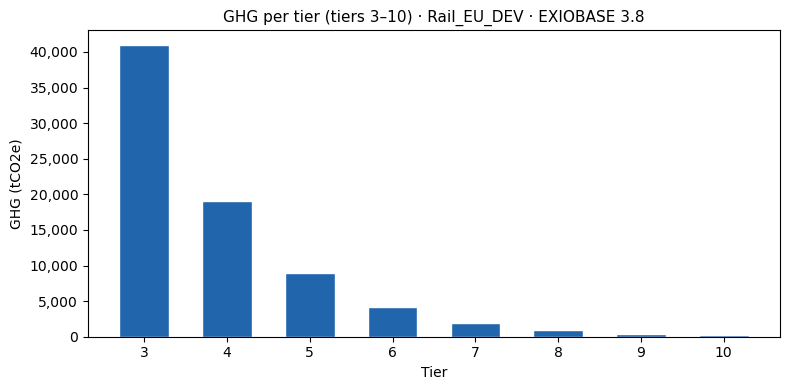

In [16]:
display(Markdown("### Tiers 3–10 · Per-tier GHG decay — Rail_EU_DEV (EXIOBASE 3.8)"))

decay_df = (t310_store[("Rail_EU_DEV", "exiobase")]
            .groupby("tier")[["spend_M$","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]]
            .sum().reset_index().set_index("tier"))
display(decay_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(decay_df.index, decay_df["GHG_tCO2e"], color="#2166ac", width=0.6, edgecolor="white")
ax.set_xlabel("Tier")
ax.set_ylabel("GHG (tCO2e)")
ax.set_title("GHG per tier (tiers 3–10) · Rail_EU_DEV · EXIOBASE 3.8", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.show()


### Tiers 3–10 · Cross-database decay comparison for Rail_EU_DEV

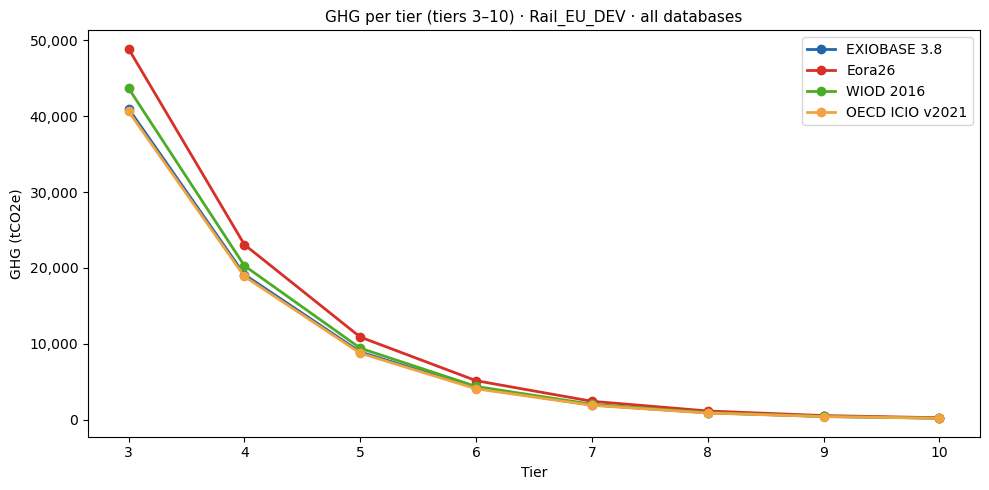

In [17]:
display(Markdown("### Tiers 3–10 · Cross-database decay comparison for Rail_EU_DEV"))

fig, ax = plt.subplots(figsize=(10, 5))
for db, color in zip(DATABASES, DB_COLORS):
    df310 = t310_store[("Rail_EU_DEV", db)]
    by_tier = df310.groupby("tier")["GHG_tCO2e"].sum().reset_index()
    ax.plot(by_tier["tier"], by_tier["GHG_tCO2e"],
            marker="o", label=DB_LABEL[db], color=color, linewidth=2)

ax.set_xlabel("Tier")
ax.set_ylabel("GHG (tCO2e)")
ax.set_title("GHG per tier (tiers 3–10) · Rail_EU_DEV · all databases", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.show()


In [18]:
t310_agg_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df310 = t310_store[(p["id"], db)]
        t310_agg_rows.append({
            "Project": p["id"], "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df310["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df310["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df310["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df310["ValueAdded_M$"].sum(), 4),
        })
t310_agg_df = pd.DataFrame(t310_agg_rows)

display(Markdown("### Tiers 3–10 — Aggregate (sum of tiers 3 to 10) · all projects × databases"))
display(t310_agg_df.set_index(["Project","Database"]))


### Tiers 3–10 — Aggregate (sum of tiers 3 to 10) · all projects × databases

GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project     Database                                                   
Rail_EU_DEV EXIOBASE 3.8    76,670.600       2,694.270       611.808   
            Eora26          92,345.830       3,824.110       757.801   
            WIOD 2016       81,386.600       3,726.290       633.876   
            OECD ICIO v2021 75,709.320       3,211.850       649.271   
Rail_EU_OP1 EXIOBASE 3.8         4.400           0.150         0.035   
            Eora26               5.300           0.220         0.044   
            WIOD 2016            4.660           0.210         0.036   
            OECD ICIO v2021      4.360           0.180         0.037   
Rail_EU_OP2 EXIOBASE 3.8         3.040           0.100         0.024   
            Eora26               3.670           0.150         0.030   
            WIOD 2016            3.230           0.150         0.025   
            OECD ICIO v2021      3.020           0.130         0.026   

                             ValueAdded_M$  
Project     Database                        
Rail_EU_DEV EXIOBASE 3.8           238.542  
            Eora26                 251.787  
            WIOD 2016              237.359  
            OECD ICIO v2021        238.507  
Rail_EU_OP1 EXIOBASE 3.8             0.014  
            Eora26                   0.015  
            WIOD 2016                0.014  
            OECD ICIO v2021          0.014  
Rail_EU_OP2 EXIOBASE 3.8             0.009  
            Eora26                   0.010  
            WIOD 2016                0.009  
            OECD ICIO v2021          0.009

---
## 8 · Cumulative Analysis — T0 + T1 + T2 + T3–10

Summing across all tier groups gives the full supply-chain footprint, approximating
the complete Scope 3 embodied impact.  The residual beyond tier 10 is < 0.5 %
for this A matrix and is not material for reporting.

The stacked bar chart below decomposes total GHG by tier group and database for
all three projects, making cross-database uncertainty immediately visible.  The
width of the cross-database spread is a direct measure of MRIO-induced uncertainty
— an important disclosure for any investor-grade impact assessment.


In [19]:
cumul_rows = []
for p in PROJECTS:
    for db in DATABASES:
        lbl = DB_LABEL[db]
        g0  = next(r["GHG_tCO2e"]      for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e0  = next(r["Employment_FTE"]  for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w0  = next(r["Water_1000m3"]    for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v0  = next(r["ValueAdded_M$"]   for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g1  = next(r["GHG_tCO2e"]      for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e1  = next(r["Employment_FTE"]  for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w1  = next(r["Water_1000m3"]    for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v1  = next(r["ValueAdded_M$"]   for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g2  = next(r["GHG_tCO2e"]      for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e2  = next(r["Employment_FTE"]  for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w2  = next(r["Water_1000m3"]    for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v2  = next(r["ValueAdded_M$"]   for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        r310 = next(r for r in t310_agg_rows if r["Project"]==p["id"] and r["Database"]==lbl)
        cumul_rows.append({
            "Project": p["id"], "Database": lbl,
            "GHG_T0": g0, "GHG_T1": g1, "GHG_T2": g2, "GHG_T3_10": r310["GHG_tCO2e"],
            "GHG_Total":  round(g0+g1+g2+r310["GHG_tCO2e"], 2),
            "Emp_T0": e0, "Emp_T1": e1, "Emp_T2": e2, "Emp_T3_10": r310["Employment_FTE"],
            "Emp_Total":  round(e0+e1+e2+r310["Employment_FTE"], 2),
            "Wat_Total":  round(w0+w1+w2+r310["Water_1000m3"], 4),
            "VA_Total":   round(v0+v1+v2+r310["ValueAdded_M$"], 4),
        })
cumul_df = pd.DataFrame(cumul_rows)

display(Markdown("### Cumulative GHG by tier group (tCO2e)"))
display(cumul_df[["Project","Database","GHG_T0","GHG_T1","GHG_T2","GHG_T3_10","GHG_Total"]]
        .set_index(["Project","Database"]))

display(Markdown("### Cumulative totals — all four indicators"))
display(cumul_df[["Project","Database","GHG_Total","Emp_Total","Wat_Total","VA_Total"]]
        .set_index(["Project","Database"]))


### Cumulative GHG by tier group (tCO2e)

GHG_T0      GHG_T1      GHG_T2  GHG_T3_10  \
Project     Database                                                         
Rail_EU_DEV EXIOBASE 3.8    379,712.960 221,692.900  87,847.280 76,670.600   
            Eora26          432,959.550 258,858.790 103,595.480 92,345.830   
            WIOD 2016       409,742.030 238,264.010  94,069.690 81,386.600   
            OECD ICIO v2021 382,399.970 221,870.940  87,489.110 75,709.320   
Rail_EU_OP1 EXIOBASE 3.8         20.240      12.560       5.030      4.400   
            Eora26               23.630      14.710       5.940      5.300   
            WIOD 2016            22.300      13.500       5.380      4.660   
            OECD ICIO v2021      20.520      12.590       5.020      4.360   
Rail_EU_OP2 EXIOBASE 3.8         14.010       8.690       3.480      3.040   
            Eora26               16.360      10.180       4.110      3.670   
            WIOD 2016            15.440       9.350       3.730      3.230   
            OECD ICIO v2021      14.210       8.720       3.480      3.020   

                              GHG_Total  
Project     Database                     
Rail_EU_DEV EXIOBASE 3.8    765,923.740  
            Eora26          887,759.650  
            WIOD 2016       823,462.330  
            OECD ICIO v2021 767,469.340  
Rail_EU_OP1 EXIOBASE 3.8         42.230  
            Eora26               49.580  
            WIOD 2016            45.840  
            OECD ICIO v2021      42.490  
Rail_EU_OP2 EXIOBASE 3.8         29.220  
            Eora26               34.320  
            WIOD 2016            31.750  
            OECD ICIO v2021      29.430

### Cumulative totals — all four indicators

GHG_Total  Emp_Total  Wat_Total  VA_Total
Project     Database                                                   
Rail_EU_DEV EXIOBASE 3.8    765,923.740 26,975.880  5,174.304 2,121.864
            Eora26          887,759.650 36,195.150  6,059.776 2,153.990
            WIOD 2016       823,462.330 36,995.880  5,380.315 2,123.403
            OECD ICIO v2021 767,469.340 31,964.700  5,493.900 2,128.447
Rail_EU_OP1 EXIOBASE 3.8         42.230      1.630      0.353     0.147
            Eora26               49.580      2.190      0.416     0.149
            WIOD 2016            45.840      2.230      0.369     0.147
            OECD ICIO v2021      42.490      1.930      0.378     0.148
Rail_EU_OP2 EXIOBASE 3.8         29.220      1.120      0.244     0.102
            Eora26               34.320      1.510      0.288     0.103
            WIOD 2016            31.750      1.540      0.255     0.102
            OECD ICIO v2021      29.430      1.340      0.262     0.102

---
## 4b · Optional Indicators (database-specific satellite accounts)

Additional indicators are served when the selected database provides the relevant
satellite extension beyond the core four (GHG / Employment / Water / Value Added).

| Database | Additional indicators | Unit |
|---|---|---|
| EXIOBASE / iopy ExioBase | `Energy_TJ` — energy input; `NOx_t` — nitrogen-oxide air emissions | TJ / t per M$ |
| WIOD | `Emp_HighSkill_FTE`, `Emp_MedSkill_FTE`, `Emp_LowSkill_FTE` — skill-level employment | FTE per M$ |
| Eora26 / OECD | `LaborIncome_M$` — labour compensation (wages + salaries) | M$ per M$ |

In [20]:
# ── Optional extended indicators from database-specific satellite accounts ──
unit_map = {"Energy_TJ":"TJ","NOx_t":"t","Emp_HighSkill_FTE":"FTE",
            "Emp_MedSkill_FTE":"FTE","Emp_LowSkill_FTE":"FTE","LaborIncome_M$":"M$"}

opt_rows = []
for row in t0_rows:
    opt = row["_r"].get("optional_indicators", {})
    if not opt:
        continue
    opt_rows.append({"Project": row["Project"], "Database": row["Database"], **opt})

if opt_rows:
    opt_df = pd.DataFrame(opt_rows)
    ind_cols = [c for c in opt_df.columns if c not in ("Project","Database")]
    opt_df[ind_cols] = opt_df[ind_cols].round(1)
    units_row = {c: f"[{unit_map.get(c,'?')}]" for c in ind_cols}
    units_row.update({"Project":"", "Database":"unit"})
    display(Markdown("### Tier 0 — Optional indicators by project and database"))
    display(pd.concat([pd.DataFrame([units_row]), opt_df],
                       ignore_index=True).set_index(["Project","Database"]))
else:
    avail_dbs = list({r["Database"] for r in t0_rows})
    display(Markdown(f"*No optional indicators available for the selected database(s): {avail_dbs}*"))

### Tier 0 — Optional indicators by project and database

Energy_TJ     NOx_t LaborIncome_M$  \
Project     Database                                             
            unit                 [TJ]       [t]           [M$]   
Rail_EU_DEV EXIOBASE 3.8    4,439.800 1,649.600            NaN   
            Eora26                NaN       NaN        589.000   
            WIOD 2016             NaN       NaN            NaN   
            OECD ICIO v2021       NaN       NaN        637.400   
Rail_EU_OP1 EXIOBASE 3.8        0.500     0.100            NaN   
            Eora26                NaN       NaN          0.000   
            WIOD 2016             NaN       NaN            NaN   
            OECD ICIO v2021       NaN       NaN          0.000   
Rail_EU_OP2 EXIOBASE 3.8        0.300     0.100            NaN   
            Eora26                NaN       NaN          0.000   
            WIOD 2016             NaN       NaN            NaN   
            OECD ICIO v2021       NaN       NaN          0.000   

                            Emp_HighSkill_FTE Emp_MedSkill_FTE  \
Project     Database                                             
            unit                        [FTE]            [FTE]   
Rail_EU_DEV EXIOBASE 3.8                  NaN              NaN   
            Eora26                        NaN              NaN   
            WIOD 2016               5,253.000        9,015.800   
            OECD ICIO v2021               NaN              NaN   
Rail_EU_OP1 EXIOBASE 3.8                  NaN              NaN   
            Eora26                        NaN              NaN   
            WIOD 2016                   0.400            0.600   
            OECD ICIO v2021               NaN              NaN   
Rail_EU_OP2 EXIOBASE 3.8                  NaN              NaN   
            Eora26                        NaN              NaN   
            WIOD 2016                   0.300            0.400   
            OECD ICIO v2021               NaN              NaN   

                            Emp_LowSkill_FTE  
Project     Database                          
            unit                       [FTE]  
Rail_EU_DEV EXIOBASE 3.8                 NaN  
            Eora26                       NaN  
            WIOD 2016              7,207.000  
            OECD ICIO v2021              NaN  
Rail_EU_OP1 EXIOBASE 3.8                 NaN  
            Eora26                       NaN  
            WIOD 2016                  0.400  
            OECD ICIO v2021              NaN  
Rail_EU_OP2 EXIOBASE 3.8                 NaN  
            Eora26                       NaN  
            WIOD 2016                  0.200  
            OECD ICIO v2021              NaN

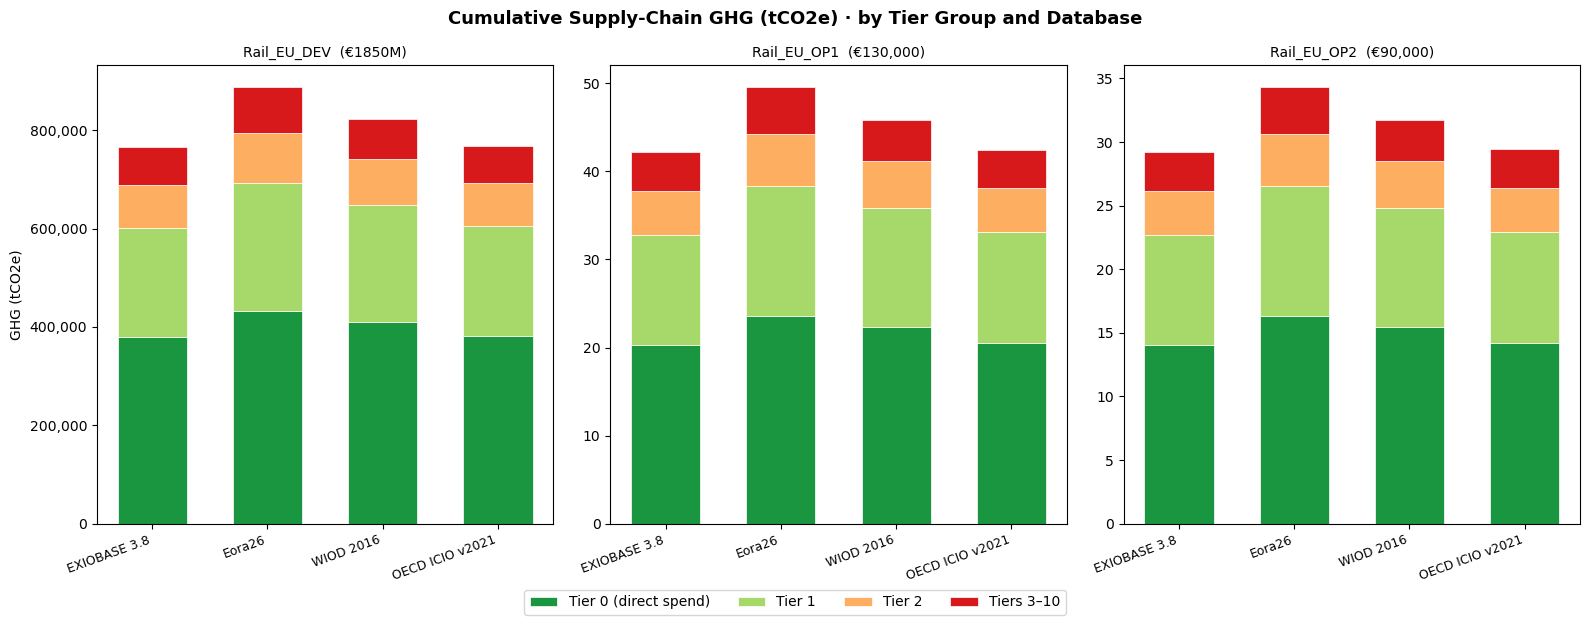

In [21]:
TIER_COLOR = {"T0": "#1a9641", "T1": "#a6d96a", "T2": "#fdae61", "T3_10": "#d7191c"}
TIER_LABEL = {"T0": "Tier 0 (direct spend)", "T1": "Tier 1",
              "T2": "Tier 2", "T3_10": "Tiers 3–10"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cumulative Supply-Chain GHG (tCO2e) · by Tier Group and Database",
             fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub    = cumul_df[cumul_df["Project"] == p["id"]].reset_index(drop=True)
    x      = range(len(DATABASES))
    bottom = np.zeros(len(DATABASES))
    for tier_key in ["T0","T1","T2","T3_10"]:
        col  = f"GHG_{tier_key}"
        vals = sub[col].values
        ax.bar(x, vals, bottom=bottom, label=TIER_LABEL[tier_key],
               color=TIER_COLOR[tier_key], width=0.6, edgecolor="white", linewidth=0.5)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    invest_str = (f"€{p['capex_eur']/1e6:.0f}M"
                  if p["capex_eur"] >= 1e6 else f"€{p['capex_eur']:,.0f}")
    ax.set_title(f"{p['id']}  ({invest_str})", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=True)
plt.tight_layout()
plt.show()
